# Construction of transcript dataset
June 17, 2025

**Goals:**
1. Update genic TSS annotations
2. Create dataset of all transcripts: Genic and non-genic (for TPM)
3. Update dataset to include promoter region and gene body region for downstream analysis.

**Parameters:**
1. max_tss_change - 500 bp How far should the TSS be allowed to be re-annotated from its original TSS call?
2. min_nongene_transcript_len - 200 bp 

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
from src.transcripts_dataset import TranscriptDatasetBuilder

builder = TranscriptDatasetBuilder(output_dir)

In [74]:
builder.load_transcripts()

Loading transcripts from all chromosomes...
Loaded 4731 gene-associated transcripts
Loaded 3156 non-genic transcripts


In [122]:
builder.update_sgd_tss_annotations()
builder.define_nongenic_dataset()

Updating TSS annotations with RNA-seq calls...
Total genes with RNA-seq TSS calls: 5206
Median difference: 14.0bp
Mean difference: -59.0bp
Std deviation: 355.3bp


In [129]:
builder.save_results()

Total genes with RNA-seq TSS calls: 5206
Median difference: 14.0bp
Mean difference: -59.0bp
Std deviation: 355.3bp


,Park_TSS,rna_TSS,tss_difference
orf_name,,,
YAL063C,28212,24994.0,3218.0
YAL062W,31189,31257.0,68.0
YAL061W,33360,NaN,NaN
YAL060W,35108,NaN,NaN
YAL059W,36560,36534.0,-26.0
...,...,...,...
YPR198W,933984,934018.0,34.0
YPR199C,939059,938977.0,82.0
YPR200C,939779,941098.0,-1319.0


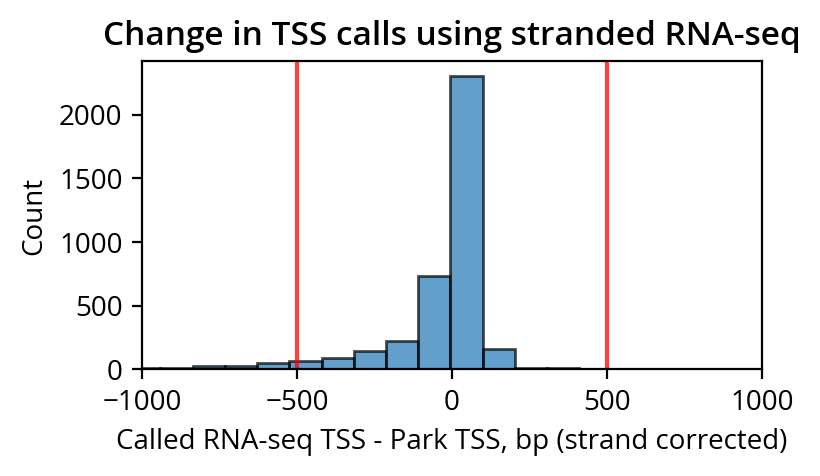

In [130]:
from src.transcripts_dataset import compare_all_chromosomes_TSS

compare_all_chromosomes_TSS(builder.rna_called_tss_data, 'Park_TSS',
    threshold=builder.max_tss_change, plot=True)
